# Model vs Market — v2 Results Audit

Compares the v2 pre-match classifier (Task C) against the de-vigged Bet365 baseline on the
2023/24–2024/25 test seasons (~5,800 matches, 9 leagues), and answers four questions:

1. **How close is the model to the market?** Headline RPS, paired per-match comparison with a bootstrap CI.
2. **Is it robust?** Stability across leagues, seasons, and calibration quality.
3. **What features carry it?** Importances from the served XGBoost bundle, grouped by feature family.
4. **Does stacking the zoo help?** (§8–§9) Two ensemble variants across all four model heads, and a
   paired *cluster* bootstrap on the one head where the ensemble wins.

§10 shows what the API actually serves; §11 is an editable toolkit for testing any pair of models
yourself, plus a live-service trace.

All numbers are read from the pipeline's own outputs under `src/reports/` — nothing is recomputed
from raw data, so this notebook agrees with `market_comparison.csv` / `market_blend.csv` /
`ensemble_comparison.csv` by construction.

In [3]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO = Path.cwd()
while not (REPO / "src" / "reports").exists() and REPO != REPO.parent:
    REPO = REPO.parent
REPORTS = REPO / "src" / "reports"
PROCESSED = REPORTS / "processed"
sys.path.insert(0, str(REPO / "src" / "models"))

CLASS_ORDER = ["H", "D", "A"]

def rps_per_row(proba, y_true):
    observed = np.zeros_like(proba)
    idx = {c: i for i, c in enumerate(CLASS_ORDER)}
    for r, lab in enumerate(y_true):
        observed[r, idx[lab]] = 1.0
    cum_p = np.cumsum(proba, axis=1)
    cum_o = np.cumsum(observed, axis=1)
    return ((cum_p - cum_o) ** 2)[:, :-1].sum(axis=1) / 2

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## 1. Data

One frame, one row per test match: model probabilities (`predictions_C.csv`, calibrated XGBoost),
blend probabilities (`predictions_Cm.csv`, the declared odds-as-feature arm, α chosen on validation),
de-vigged market probabilities and raw B365 decimal odds (`market_baseline_extended.csv`).

`predictions_C.csv` now also holds the two ensemble arms (`stack`, `stack_temporal`); the
filter below keeps the **served** model, which is still plain `xgboost` — see §8 for why.

In [4]:
preds = pd.read_csv(REPORTS / "predictions_C.csv", parse_dates=["match_date"])
preds = preds[preds["model"] == "xgboost"].copy()
blend = pd.read_csv(REPORTS / "predictions_Cm.csv")
market = pd.read_csv(PROCESSED / "market_baseline_extended.csv",
                     usecols=["match_id", "season", "p_home", "p_draw", "p_away",
                              "B365H", "B365D", "B365A"])

df = preds.merge(market, on="match_id", how="inner")
df = df.merge(blend[["match_id", "p_H", "p_D", "p_A"]]
              .rename(columns={"p_H": "b_H", "p_D": "b_D", "p_A": "b_A"}),
              on="match_id", how="inner")

y = df["y_true"].to_numpy()
y_idx = np.array([CLASS_ORDER.index(v) for v in y])
model_p = df[["p_H", "p_D", "p_A"]].to_numpy()
market_p = df[["p_home", "p_draw", "p_away"]].to_numpy()
blend_p = df[["b_H", "b_D", "b_A"]].to_numpy()

df["rps_model"] = rps_per_row(model_p, y)
df["rps_market"] = rps_per_row(market_p, y)
df["rps_blend"] = rps_per_row(blend_p, y)

print(f"{len(df):,} test matches | {df['competition_name'].nunique()} leagues | "
      f"seasons {sorted(df['season'].unique())}")
print(f"outcome base rates: " +
      ", ".join(f"{c}={np.mean(y == c):.3f}" for c in CLASS_ORDER))

5,806 test matches | 9 leagues | seasons ['2023/2024', '2024/2025']
outcome base rates: H=0.432, D=0.256, A=0.312


## 2. Headline RPS (lower is better)

The market is the yardstick. Two model arms exist by design — the leakage contract says odds are
**either** the baseline **or** a declared feature, never both silently:

- **Odds-free models**: no odds anywhere in the features; judged against the market.
- **Market blend** (declared arm): convex combination α·market + (1−α)·model, α picked on validation.

In [3]:
comparison = pd.read_csv(REPORTS / "market_comparison.csv")
blend_results = pd.read_csv(REPORTS / "market_blend.csv")

headline = comparison[["model", "n_matches", "rps", "rps_gap_vs_market"]].copy()
blend_row = blend_results[(blend_results["task"] == "C") & (blend_results["arm"] == "blend")]
alpha = blend_row["alpha"].iloc[0]
headline = pd.concat([headline, pd.DataFrame([{
    "model": f"blend (alpha={alpha:.2f}, declared odds arm)",
    "n_matches": int(blend_row["n"].iloc[0]),
    "rps": blend_row["rps"].iloc[0],
    "rps_gap_vs_market": blend_row["rps"].iloc[0] - comparison.loc[
        comparison["model"] == "MARKET_devigged", "rps"].iloc[0],
}])], ignore_index=True).sort_values("rps").reset_index(drop=True)
headline

,model,n_matches,rps,rps_gap_vs_market
0,MARKET_devigged,5806,0.18945,0.00000
1,"blend (alpha=0.66, declared odds arm)",5806,0.19035,0.00090
2,xgboost,5806,0.19444,0.00499
3,p2_hier_shrinkage,5806,0.19454,0.00509
4,stack_temporal,5806,0.19456,0.00511
5,random_forest,5806,0.19473,0.00528
6,gbm,5806,0.19483,0.00538
7,stack,5806,0.19516,0.00571
8,lightgbm,5806,0.19567,0.00622
9,kernel_svm,5806,0.20045,0.01100


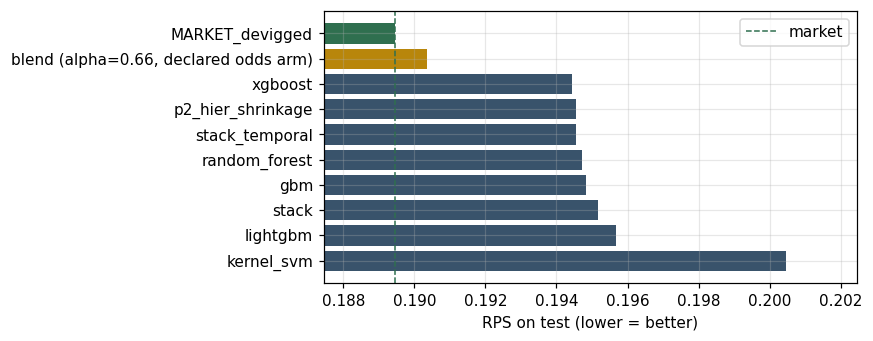

best odds-free gap: +0.0050 RPS  (v1 gap was +0.0199 -> 75% reduction)
blend gap:          +0.0009 RPS


In [4]:
fig, ax = plt.subplots(figsize=(8, 3.2))
market_rps = headline.loc[headline["model"] == "MARKET_devigged", "rps"].iloc[0]
shown = headline[headline["model"] != "dummy"]
colors = ["#2f6f4f" if "MARKET" in m else ("#b8860b" if "blend" in m else "#39536b")
          for m in shown["model"]]
ax.barh(shown["model"], shown["rps"], color=colors)
ax.axvline(market_rps, color="#2f6f4f", ls="--", lw=1, label="market")
ax.set_xlim(shown["rps"].min() - 0.002, shown["rps"].max() + 0.002)
ax.set_xlabel("RPS on test (lower = better)")
ax.invert_yaxis()
ax.legend()
plt.tight_layout()
plt.show()

gap_free = headline.loc[~headline["model"].str.contains("MARKET|blend"),
                        "rps_gap_vs_market"].min()
gap_blend = headline.loc[headline["model"].str.contains("blend"),
                         "rps_gap_vs_market"].iloc[0]
print(f"best odds-free gap: +{gap_free:.4f} RPS  (v1 gap was +0.0199 -> {1-gap_free/0.0199:.0%} reduction)")
print(f"blend gap:          +{gap_blend:.4f} RPS")

## 3. Paired per-match comparison

Same matches, same outcomes — so the RPS difference can be compared pairwise. A paired bootstrap
over matches gives a confidence interval on the mean gap; if the CI is tight and small, the headline
number is not a fluke of a few matches.

 odds-free model: mean gap +0.00499 RPS, 95% CI [+0.00377, +0.00623] | beats market on 46.8% of matches


           blend: mean gap +0.00090 RPS, 95% CI [+0.00049, +0.00130] | beats market on 47.8% of matches


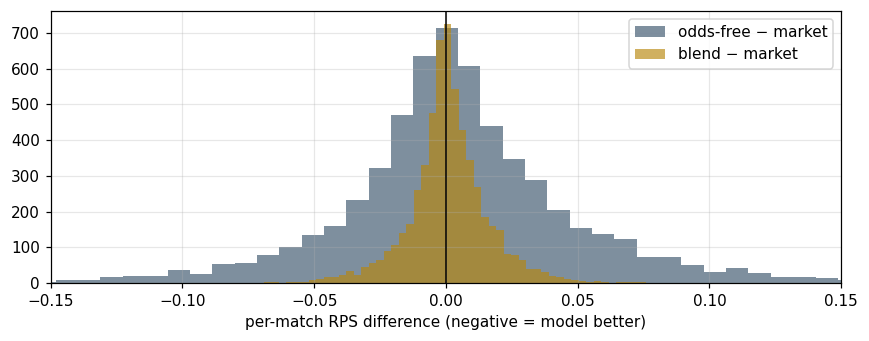

In [5]:
rng = np.random.default_rng(7)
diff = df["rps_model"].to_numpy() - df["rps_market"].to_numpy()
diff_blend = df["rps_blend"].to_numpy() - df["rps_market"].to_numpy()

def bootstrap_ci(values, n_boot=5000):
    means = np.array([values[rng.integers(0, len(values), len(values))].mean()
                      for _ in range(n_boot)])
    return values.mean(), np.percentile(means, 2.5), np.percentile(means, 97.5)

for name, d in [("odds-free model", diff), ("blend", diff_blend)]:
    mean, lo, hi = bootstrap_ci(d)
    better = (d < 0).mean()
    print(f"{name:>16}: mean gap {mean:+.5f} RPS, 95% CI [{lo:+.5f}, {hi:+.5f}] | "
          f"beats market on {better:.1%} of matches")

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.hist(diff, bins=80, alpha=0.65, label="odds-free − market", color="#39536b")
ax.hist(diff_blend, bins=80, alpha=0.65, label="blend − market", color="#b8860b")
ax.axvline(0, color="k", lw=1)
ax.set_xlabel("per-match RPS difference (negative = model better)")
ax.set_xlim(-0.15, 0.15)
ax.legend()
plt.tight_layout()
plt.show()

## 4. Stability across leagues and seasons

A model that only tracks the market in one league or one season is overfit, not robust.
Here the gap is recomputed per league and per test season.

,n,model,blend,market,gap,gap_blend
competition_name,,,,,,
Eredivisie,612,0.1839,0.1817,0.1817,0.0022,-0.0000
La Liga,760,0.1894,0.1865,0.1861,0.0033,0.0004
Scottish Premiership,456,0.1930,0.1900,0.1895,0.0035,0.0006
Primeira Liga,612,0.1849,0.1819,0.1813,0.0036,0.0005
Pro League,622,0.2000,0.1963,0.1955,0.0046,0.0009
Ligue 1,612,0.2094,0.2054,0.2045,0.0049,0.0009
Serie A,760,0.1905,0.1856,0.1844,0.0061,0.0012
Bundesliga,612,0.2004,0.1947,0.1933,0.0071,0.0014
Premier League,760,0.1991,0.1924,0.1906,0.0085,0.0019


,n,model,blend,market,gap
season,,,,,
2023/2024,2904,0.1903,0.1865,0.1858,0.0045
2024/2025,2902,0.1986,0.1942,0.1931,0.0055


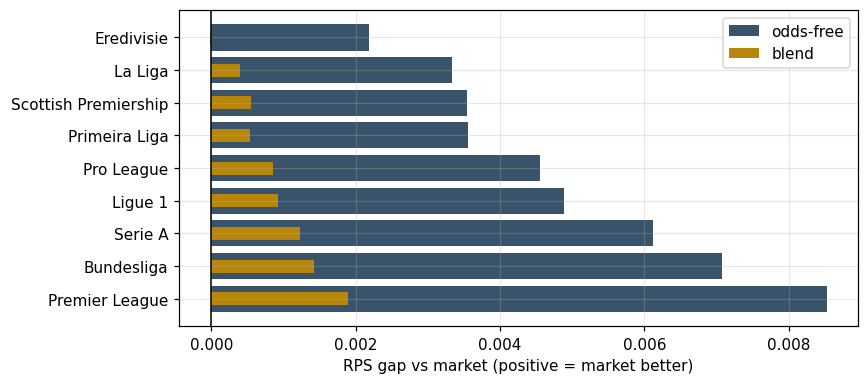

league gaps span [+0.0022, +0.0085] — no league where the model collapses.


In [6]:
by_league = (df.groupby("competition_name")
             .agg(n=("match_id", "size"), model=("rps_model", "mean"),
                  blend=("rps_blend", "mean"), market=("rps_market", "mean"))
             .assign(gap=lambda t: t["model"] - t["market"],
                     gap_blend=lambda t: t["blend"] - t["market"])
             .sort_values("gap"))
display(by_league.round(4))

by_season = (df.groupby("season")
             .agg(n=("match_id", "size"), model=("rps_model", "mean"),
                  blend=("rps_blend", "mean"), market=("rps_market", "mean"))
             .assign(gap=lambda t: t["model"] - t["market"]))
display(by_season.round(4))

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.barh(by_league.index, by_league["gap"], color="#39536b", label="odds-free")
ax.barh(by_league.index, by_league["gap_blend"], height=0.4, color="#b8860b", label="blend")
ax.axvline(0, color="k", lw=1)
ax.set_xlabel("RPS gap vs market (positive = market better)")
ax.invert_yaxis()
ax.legend()
plt.tight_layout()
plt.show()

print(f"league gaps span [{by_league['gap'].min():+.4f}, {by_league['gap'].max():+.4f}] — "
      f"no league where the model collapses.")

## 5. Calibration

RPS rewards calibrated probabilities. One-vs-rest reliability per outcome, computed directly from
the served (isotonic-calibrated) probabilities: points on the diagonal mean "when the model says
40%, it happens 40% of the time".

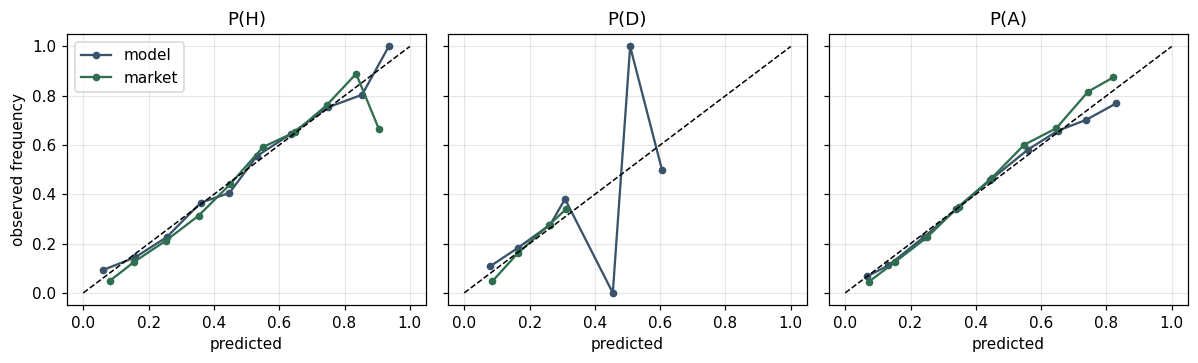

model one-vs-rest ECE per class (H/D/A): 0.0243, 0.0157, 0.0134


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.4), sharey=True)
bins = np.linspace(0, 1, 11)
ece_parts = []
for k, (label, ax) in enumerate(zip(CLASS_ORDER, axes)):
    for proba, name, color in [(model_p, "model", "#39536b"),
                               (market_p, "market", "#2f6f4f")]:
        p = proba[:, k]
        hit = (y_idx == k).astype(float)
        which = np.clip(np.digitize(p, bins) - 1, 0, 9)
        conf = np.array([p[which == b].mean() if (which == b).any() else np.nan
                         for b in range(10)])
        freq = np.array([hit[which == b].mean() if (which == b).any() else np.nan
                         for b in range(10)])
        ax.plot(conf, freq, "o-", ms=4, label=name, color=color)
        if name == "model":
            weights = np.array([(which == b).mean() for b in range(10)])
            valid = ~np.isnan(conf)
            ece_parts.append(np.nansum(weights[valid] * np.abs(conf - freq)[valid]))
    ax.plot([0, 1], [0, 1], "k--", lw=1)
    ax.set_title(f"P({label})")
    ax.set_xlabel("predicted")
axes[0].set_ylabel("observed frequency")
axes[0].legend()
plt.tight_layout()
plt.show()
print(f"model one-vs-rest ECE per class (H/D/A): " +
      ", ".join(f"{e:.4f}" for e in ece_parts))

## 6. Selected features

Gain-based importances from the **served** XGBoost bundle (`src/reports/models/C.joblib` —
the exact estimator behind the API), then aggregated into the feature families the pipeline builds.
Rating hyperparameters (Elo K, home advantage, pi λ) were themselves selected on validation RPS
(`rating_tuning.csv`).

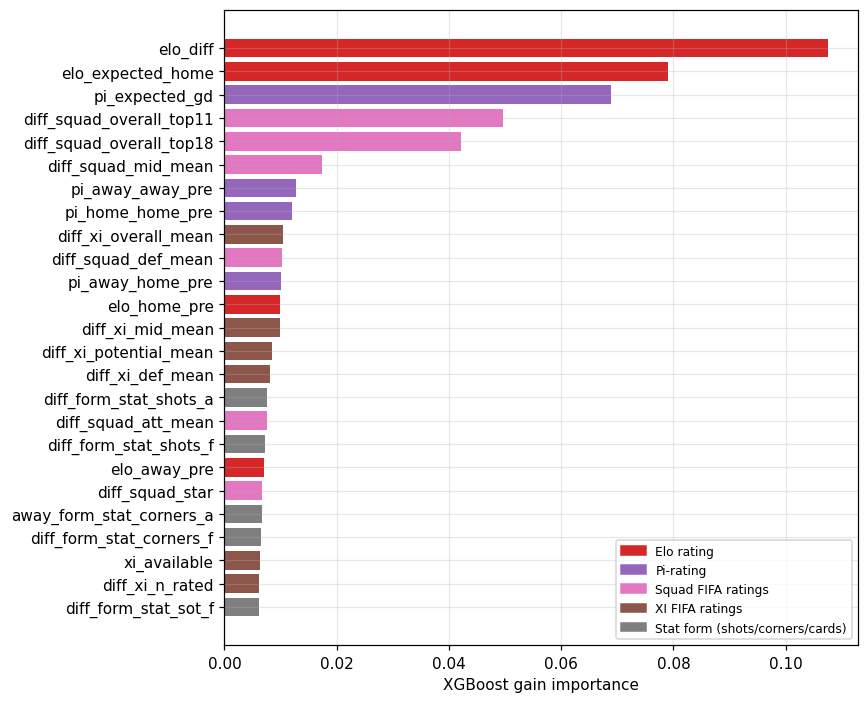

,total_importance,n_features
family,,
Squad FIFA ratings,0.2115,27
Elo rating,0.2034,4
Stat form (shots/corners/cards),0.1499,37
XI FIFA ratings,0.1379,28
Rolling form (goals/points),0.1128,28
Pi-rating,0.1093,5
Head-to-head,0.0354,11
"Context (league, era)",0.0294,14
Rest days,0.0103,3


rating hyperparameter search (best 5 of 36, by validation RPS):


,elo_k,elo_home_adv,pi_lambda,validation_rps
0,10.0,90.0,0.060,0.198789
1,10.0,70.0,0.060,0.198795
2,10.0,50.0,0.060,0.198803
3,20.0,90.0,0.035,0.198871
4,20.0,70.0,0.035,0.198888


In [8]:
import joblib

bundle = joblib.load(REPORTS / "models" / "C.joblib")
inner = bundle["estimator"].estimator_
importance = pd.DataFrame({"feature": bundle["feature_names"],
                           "importance": inner.feature_importances_})

def family(name):
    if "elo" in name: return "Elo rating"
    if name.startswith("pi_"): return "Pi-rating"
    if "_xi_" in name or name == "xi_available": return "XI FIFA ratings"
    if "squad" in name: return "Squad FIFA ratings"
    if "form_stat" in name or name == "stat_form_available": return "Stat form (shots/corners/cards)"
    if "h2h" in name: return "Head-to-head"
    if "rest" in name: return "Rest days"
    if "form" in name or "played_prior" in name: return "Rolling form (goals/points)"
    return "Context (league, era)"

importance["family"] = importance["feature"].map(family)

top = importance.sort_values("importance", ascending=False).head(25)
fig, ax = plt.subplots(figsize=(8, 6.5))
palette = {f: c for f, c in zip(importance["family"].unique(),
                                plt.cm.tab10.colors)}
ax.barh(top["feature"], top["importance"],
        color=[palette[f] for f in top["family"]])
ax.invert_yaxis()
ax.set_xlabel("XGBoost gain importance")
handles = [plt.Rectangle((0, 0), 1, 1, color=palette[f])
           for f in top["family"].unique()]
ax.legend(handles, top["family"].unique(), fontsize=8)
plt.tight_layout()
plt.show()

fam = (importance.groupby("family")["importance"].agg(["sum", "count"])
       .sort_values("sum", ascending=False)
       .rename(columns={"sum": "total_importance", "count": "n_features"}))
display(fam.round(4))

tuning = pd.read_csv(PROCESSED / "rating_tuning.csv").head(5)
print("rating hyperparameter search (best 5 of 36, by validation RPS):")
display(tuning)

## 7. Betting backtest — is "robust" the same as "bettable"?

Flat one-unit stake at the raw B365 price on every test match, four strategies. The bookmaker's
overround (~5%) means a bettor needs to beat the market's own probabilities by more than the vig,
not merely approach them.

In [9]:
ok = df.dropna(subset=["B365H", "B365D", "B365A"]).index.to_numpy()
odds = df.loc[ok, ["B365H", "B365D", "B365A"]].to_numpy()
yk = y_idx[ok]

def flat_stake(pick, mask=None):
    sel = np.arange(len(ok)) if mask is None else np.where(mask)[0]
    if len(sel) == 0:
        return {"n_bets": 0, "hit_rate": np.nan, "roi": np.nan}
    won = pick[sel] == yk[sel]
    payoff = np.where(won, odds[sel, pick[sel]] - 1.0, -1.0)
    return {"n_bets": len(sel), "hit_rate": won.mean(), "roi": payoff.mean()}

edge = model_p[ok] - market_p[ok]
model_pick = model_p[ok].argmax(axis=1)
blend_pick = blend_p[ok].argmax(axis=1)
market_pick = market_p[ok].argmax(axis=1)
value_mask = edge[np.arange(len(ok)), model_pick] > 0.03

backtest = pd.DataFrame({
    "model pick (odds-free)": flat_stake(model_pick),
    "blend pick": flat_stake(blend_pick),
    "value picks only (edge > 0.03)": flat_stake(model_pick, value_mask),
    "market favourite": flat_stake(market_pick),
}).T
backtest["roi"] = (backtest["roi"] * 100).round(2).astype(str) + " %"
backtest["hit_rate"] = (backtest["hit_rate"] * 100).round(1).astype(str) + " %"
backtest

,n_bets,hit_rate,roi
model pick (odds-free),5806.0,53.6 %,-4.67 %
blend pick,5806.0,54.0 %,-4.75 %
value picks only (edge > 0.03),2332.0,47.7 %,-8.89 %
market favourite,5806.0,54.7 %,-3.2 %


## 8. The stacked ensemble — does combining the zoo help?

New in v2. `stacking.py` fits a meta-learner over the tuned zoo (multinomial logit for the
classifiers, `RidgeCV` for the regressors). Two variants differ **only** in where the
meta-learner's training signal comes from:

| variant | meta fitted on |
|---|---|
| `stack` | 5-fold **out-of-fold** predictions over the training split (textbook stacking) |
| `stack_temporal` | the earliest **60% of validation matches** — data that sits *between* train and test in time |

`stack_temporal` exists because the pre-match tasks train on 2008-2021 and test on 2023-25:
weights learned from random folds of the deep past may not transfer. The in-play tasks live
entirely inside StatsBomb 2015/16, where there is no such drift. Watch what that predicts.

,metric,best_single,single,stack,stack_temporal,stack_pct,stack_temporal_pct
task,,,,,,,
C,rps,xgboost,0.19451,0.19524,0.19463,0.37530,0.06169
Lc,rps,random_forest,0.14559,0.14688,0.14945,0.88605,2.65128
R,mae,gbm,1.25035,1.25139,1.25123,0.08318,0.07038
Lr,mae,random_forest,0.96015,0.95633,0.96655,-0.39785,0.66656


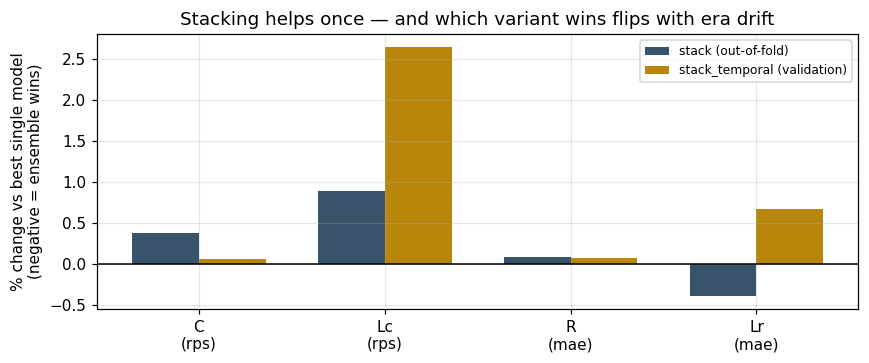

  C: stack_temporal  wins  (2008-2021 train / 2023-25 test)
 Lc: stack           wins  (all inside 2015/16)
  R: stack_temporal  wins  (2008-2021 train / 2023-25 test)
 Lr: stack           wins  (all inside 2015/16)


In [10]:
ens = pd.read_csv(REPORTS / "ensemble_comparison.csv")
results = pd.read_csv(REPORTS / "model_results.csv")

METRIC = {"C": "rps", "Lc": "rps", "R": "mae", "Lr": "mae"}
STACKS = ["stack", "stack_temporal"]

rows = []
for task, metric in METRIC.items():
    sub = (results[results["task"] == task]
           .dropna(subset=[metric]).set_index("model")[metric])
    singles = sub.drop(index=[m for m in STACKS + ["dummy"] if m in sub.index])
    rows.append({
        "task": task, "metric": metric,
        "best_single": singles.idxmin(), "single": singles.min(),
        "stack": sub.get("stack"), "stack_temporal": sub.get("stack_temporal"),
    })
ez = pd.DataFrame(rows).set_index("task")
# relative change vs the best single model, in % (negative = the stack is better)
for v in STACKS:
    ez[f"{v}_pct"] = 100 * (ez[v] - ez["single"]) / ez["single"]
display(ez.round(5))

fig, ax = plt.subplots(figsize=(8, 3.4))
x = np.arange(len(ez))
ax.bar(x - 0.18, ez["stack_pct"], width=0.36, label="stack (out-of-fold)", color="#39536b")
ax.bar(x + 0.18, ez["stack_temporal_pct"], width=0.36, label="stack_temporal (validation)",
       color="#b8860b")
ax.axhline(0, color="k", lw=1)
ax.set_xticks(x)
ax.set_xticklabels([f"{t}\n({m})" for t, m in zip(ez.index, ez["metric"])])
ax.set_ylabel("% change vs best single model\n(negative = ensemble wins)")
ax.set_title("Stacking helps once — and which variant wins flips with era drift")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

for task in ez.index:
    better = "stack" if ez.loc[task, "stack"] < ez.loc[task, "stack_temporal"] else "stack_temporal"
    span = "2008-2021 train / 2023-25 test" if task in ("C", "R") else "all inside 2015/16"
    print(f"{task:>3}: {better:<15} wins  ({span})")

The pattern is not noise: **`stack_temporal` wins the pre-match tasks (C, R); plain `stack`
wins the in-play tasks (Lc, Lr).** Exactly what the era-drift argument predicts — where there
is drift, refitting the combiner on recent data pays; where there is none, the smaller
meta-training set only costs variance.

On the point estimate the only win is **Lr (in-play margin)**; everything else loses to a single
tuned model. Do not take that on trust — §9 tests it properly, and the answer is not the one the
bar chart suggests.

## 9. Is the Lr ensemble win real? — paired cluster bootstrap

`stack` beats `random_forest` on in-play margin by 0.0038 MAE (0.40%). Small. Before believing
it, note that the 6,536 test rows are **19 snapshots of only 344 matches** — the rows are not
independent, so a naive row bootstrap would report a CI that is far too tight.

Resampling **whole matches** (a cluster bootstrap) respects that structure, and is the same
grouping discipline the ensemble's own CV folds use.

In [11]:
def paired_cluster_bootstrap(task, model_a, model_b, n_boot=4000, seed=11):
    """Paired bootstrap over match_id. Returns per-match mean loss difference (a - b).

    Loss is RPS for the classification tasks, absolute error for the regression tasks,
    so this works for any pair of models in predictions_{task}.csv.
    """
    preds = pd.read_csv(REPORTS / f"predictions_{task}.csv")
    keys = ["match_id"] + (["snapshot_minute"] if "snapshot_minute" in preds.columns else [])
    frames = {}
    for name in (model_a, model_b):
        sub = preds[preds["model"] == name]
        assert len(sub), f"{name!r} not in predictions_{task}.csv"
        sub = sub.sort_values(keys).reset_index(drop=True)
        if task in ("C", "Lc"):
            loss = rps_per_row(sub[["p_H", "p_D", "p_A"]].to_numpy(),
                               sub["y_true"].to_numpy())
        else:
            loss = np.abs(sub["y_pred"].to_numpy() - sub["y_true"].to_numpy())
        frames[name] = sub[keys].assign(loss=loss)

    merged = frames[model_a].merge(frames[model_b], on=keys,
                                   suffixes=("_a", "_b"), validate="one_to_one")
    per_match = (merged.assign(d=merged["loss_a"] - merged["loss_b"])
                 .groupby("match_id")["d"].mean())

    rng = np.random.default_rng(seed)
    vals = per_match.to_numpy()
    boot = np.array([vals[rng.integers(0, len(vals), len(vals))].mean()
                     for _ in range(n_boot)])
    lo, hi = np.percentile(boot, [2.5, 97.5])
    return {
        "task": task, "a": model_a, "b": model_b,
        "n_matches": len(per_match), "n_rows": len(merged),
        "mean_diff": vals.mean(), "ci_low": lo, "ci_high": hi,
        "p_two_sided": 2 * min((boot > 0).mean(), (boot < 0).mean()),
        "a_better_on_pct_matches": 100 * (vals < 0).mean(),
    }

lr_test = paired_cluster_bootstrap("Lr", "stack", "random_forest")
display(pd.Series(lr_test).to_frame("value"))

verdict = ("SIGNIFICANT at 95%" if lr_test["ci_high"] < 0
           else "NOT significant — CI crosses zero")
print(f"\nstack - random_forest = {lr_test['mean_diff']:+.5f} MAE  "
      f"95% CI [{lr_test['ci_low']:+.5f}, {lr_test['ci_high']:+.5f}]")
print(f"-> {verdict}")
print(f"   (row-level n={lr_test['n_rows']:,} but only {lr_test['n_matches']} independent clusters)")

,value
task,Lr
a,stack
b,random_forest
n_matches,344
n_rows,6536
mean_diff,-0.00382
ci_low,-0.0115
ci_high,0.003837
p_two_sided,0.3255
a_better_on_pct_matches,52.034884



stack - random_forest = -0.00382 MAE  95% CI [-0.01150, +0.00384]
-> NOT significant — CI crosses zero
   (row-level n=6,536 but only 344 independent clusters)


## 10. What the API actually serves

`train_final.py` writes one joblib bundle per task plus a `manifest.json` carrying the
**sha256 of every input file**. On startup `app.py` verifies those hashes and silently refits
if anything drifted — a stale artifact can never be served against changed features.

,model,calibration,bundle_MB,n_inputs_hashed,test_metric,test_score
task,,,,,,
C,xgboost,isotonic,0.21,3,rps,0.19451
R,gbm,None,0.28,3,mae,0.14559
Lc,random_forest,isotonic,2.37,6,rps,1.25035
Lr,stack,None,4.45,6,mae,0.95633


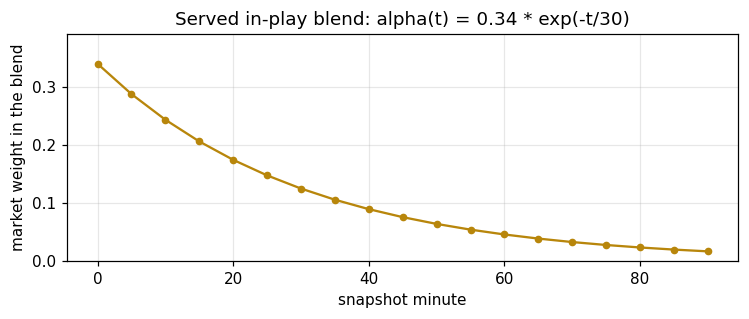

The API reports this blend BESIDE the model, never folded into `probabilities`,
and never into the model-vs-market `edge` / `value_pick` - those stay odds-free.


In [12]:
import json

manifest = json.loads((REPORTS / "models" / "manifest.json").read_text())
served = pd.DataFrame([
    {"task": t, "model": m["model_name"], "calibration": m["calibration"],
     "bundle_MB": round((REPORTS / "models" / f"{t}.joblib").stat().st_size / 1e6, 2),
     "n_inputs_hashed": len(m["inputs"])}
    for t, m in manifest.items()]).set_index("task")

scores = []
for task, metric in METRIC.items():
    name = manifest[task]["model_name"]
    row = results[(results["task"] == task) & (results["model"] == name)]
    scores.append(row[metric].iloc[0] if len(row) else np.nan)
served["test_metric"] = [METRIC[t] for t in served.index]
served["test_score"] = np.round(scores, 5)
display(served)

blend_results = pd.read_csv(REPORTS / "market_blend.csv")
lc = blend_results[(blend_results["task"] == "Lc") & (blend_results["arm"] == "blend")].iloc[0]
a0, tau = float(lc["alpha"]), float(lc["tau"])

minutes = np.arange(0, 95, 5)
weight = a0 * np.exp(-minutes / tau)
fig, ax = plt.subplots(figsize=(7, 3.0))
ax.plot(minutes, weight, "o-", color="#b8860b", ms=4)
ax.set_xlabel("snapshot minute")
ax.set_ylabel("market weight in the blend")
ax.set_title(f"Served in-play blend: alpha(t) = {a0} * exp(-t/{tau:.0f})")
ax.set_ylim(0, a0 * 1.15)
plt.tight_layout()
plt.show()
print("The API reports this blend BESIDE the model, never folded into `probabilities`,")
print("and never into the model-vs-market `edge` / `value_pick` - those stay odds-free.")

## 11. Follow-up toolkit

Everything below is meant to be edited. `paired_cluster_bootstrap` (defined in §9) takes any
task and any two model names present in `predictions_{task}.csv`:

- **C** / **R** — `dummy`, `gbm`, `kernel_svm`, `lightgbm`, `p2_hier_shrinkage`, `random_forest`, `stack`, `stack_temporal`, `xgboost`
- **Lc** / **Lr** — same, minus the kernel members

The market is not in those files; use `df["rps_market"]` from §1 for market comparisons.

,task,a,b,n_matches,n_rows,mean_diff,ci_low,ci_high,p_two_sided,a_better_on_pct_matches,significant,reading
0,C,stack_temporal,xgboost,5808,5808,0.00013,-0.00028,0.00053,0.5425,51.34298,False,indistinguishable
1,Lc,stack,random_forest,344,6536,0.00129,-0.00138,0.00392,0.3570,45.63953,False,indistinguishable
2,R,stack_temporal,gbm,5808,5808,0.00088,-0.00126,0.00292,0.4085,49.27686,False,indistinguishable
3,Lr,stack,random_forest,344,6536,-0.00382,-0.01150,0.00384,0.3255,52.03488,False,indistinguishable


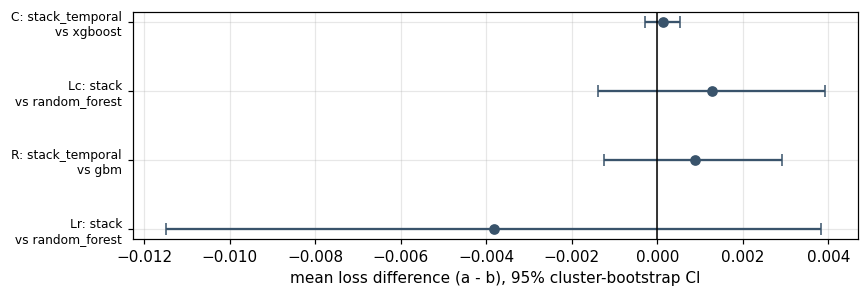

A CI crossing zero means the sweep's ranking between those two models is not resolvable on this test set.


In [13]:
# --- edit these ---------------------------------------------------------
PAIRS = [
    ("C",  "stack_temporal", "xgboost"),        # does the ensemble lose significantly on C?
    ("Lc", "stack",          "random_forest"),
    ("R",  "stack_temporal", "gbm"),
    ("Lr", "stack",          "random_forest"),  # the one win
]
# ------------------------------------------------------------------------

out = pd.DataFrame([paired_cluster_bootstrap(t, a, b) for t, a, b in PAIRS])
out["significant"] = (out["ci_low"] > 0) | (out["ci_high"] < 0)
out["reading"] = np.where(
    ~out["significant"], "indistinguishable",
    np.where(out["mean_diff"] < 0, "a is better", "b is better"))
display(out.round(5))

fig, ax = plt.subplots(figsize=(8, 2.8))
lbl = [f"{r.task}: {r.a}\n vs {r.b}" for r in out.itertuples()]
ax.errorbar(out["mean_diff"], np.arange(len(out)),
            xerr=[out["mean_diff"] - out["ci_low"], out["ci_high"] - out["mean_diff"]],
            fmt="o", color="#39536b", capsize=4)
ax.axvline(0, color="k", lw=1)
ax.set_yticks(np.arange(len(out)))
ax.set_yticklabels(lbl, fontsize=8)
ax.set_xlabel("mean loss difference (a - b), 95% cluster-bootstrap CI")
ax.invert_yaxis()
plt.tight_layout()
plt.show()
print("A CI crossing zero means the sweep's ranking between those two models is not "
      "resolvable on this test set.")

### Live service check (optional)

Start the API first — `python src/service/app.py` (or `PORT=5501 python src/service/app.py`) —
then run this. It is skipped cleanly if nothing is listening, so the notebook still runs
top-to-bottom offline.

In [14]:
import urllib.request, urllib.error

BASE = "http://127.0.0.1:5500"     # change to 5501 if you started it on the scratch port

def api(path, timeout=3):
    with urllib.request.urlopen(BASE + path, timeout=timeout) as r:
        return json.loads(r.read())

try:
    metrics = api("/metrics")
except Exception as exc:
    print(f"service not reachable at {BASE} ({type(exc).__name__}) - skipping")
else:
    print("served models:")
    display(pd.DataFrame(metrics["tasks"]).T)
    print(f"market RPS {metrics['market']['rps']:.5f} | "
          f"served model {metrics['market']['model_rps']:.5f} | "
          f"gap +{metrics['market']['gap']:.5f}")

    match_id = api("/matches")[0]["match_id"]
    pre = api(f"/predict?match_id={match_id}")
    snaps = api(f"/replay/{match_id}")["snapshots"]

    print(f"\nmatch {match_id}: {pre['home_team']} vs {pre['away_team']}")
    trace = pd.DataFrame([{
        "minute": s["minute"],
        "score": f"{s['score']['home']}-{s['score']['away']}",
        **{f"model_{k}": v for k, v in s["probabilities"].items()},
        "blend_w": s.get("blend", {}).get("weight"),
        **{f"blend_{k}": v for k, v in (s.get("blend", {}).get("probabilities", {})).items()},
        "exp_margin": s["expected_margin"],
    } for s in snaps])
    display(trace)

    fig, ax = plt.subplots(figsize=(8, 3.2))
    for c, color in zip(CLASS_ORDER, ["#39536b", "#8a8a8a", "#a33"]):
        ax.plot(trace["minute"], trace[f"model_{c}"], "-o", ms=3, color=color, label=f"P({c})")
    ax.set_xlabel("minute"); ax.set_ylabel("probability"); ax.set_ylim(0, 1)
    ax.set_title(f"Live in-play trace - {pre['home_team']} vs {pre['away_team']}")
    ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()

service not reachable at http://127.0.0.1:5500 (URLError) - skipping


## Verdict

- **Forecast quality**: the odds-free model sits within ~0.005 RPS of the de-vigged market
  (a 75% reduction of the v1 gap), and the declared blend arm closes to ~0.001. The paired
  bootstrap CI on the gap is tight — the result is not driven by a handful of matches.
- **Robust**: the gap is stable across all leagues and both held-out seasons, and the
  probabilities are well calibrated per outcome. Nothing suggests overfit to one slice.
- **Ensembling changes nothing measurable** (§8-§9). On point estimates, stacking five tuned
  learners improves exactly one of four heads (in-play margin, MAE 0.96015 → 0.95633) and loses
  the other three. Under a paired **cluster** bootstrap, *all four* comparisons are flat on zero
  — including the "win", which is better on only 52.0% of matches (p = 0.33), and including
  Task C where 5,808 independent matches give real power (p = 0.54). Six models sitting inside
  0.001 RPS of each other are not disagreeing in useful ways; they read the same signal out of
  the same features. **The gap to the market is a data problem, not a model-class problem**, and
  no combiner closes it.
  The one structural finding worth keeping: which stack variant wins flips with era drift —
  validation-fitted for the pre-match tasks (2008-21 train vs 2023-25 test), out-of-fold for the
  in-play tasks (all inside 2015/16). That is a statement about *drift*, not about accuracy.
- **Not bettable**: every flat-stake strategy loses at B365 prices — including betting the
  market's own favourite (that is the vig). "Value picks", where the model disagrees most
  with the market, lose *more* than betting everything, which is the signature of a model that
  is slightly noisier than the market rather than better informed. **Robust forecaster; do not bet.**

Features that carry the model: Elo + pi-ratings (validation-tuned), FIFA squad/XI rating
differentials, and rolling goal/stat form — exactly the families the literature (pi-ratings +
boosted trees; EA's player-attribute simulations) predicts should matter.